<a href="https://colab.research.google.com/github/ushasri0412/Data-Science-Task/blob/main/Linear_Regression_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [4]:
df=pd.read_csv("/content/car_price_prediction.csv")

In [5]:
df


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [7]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.drop("ID",axis=1,inplace=True)
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [10]:
df.drop("Doors",axis=1,inplace=True)
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4


In [11]:
df["Price"].unique()

array([13328, 16621,  8467, ..., 56814, 63886, 22075])

In [12]:
df["Levy"].unique()

array(['1399', '1018', '-', '862', '446', '891', '761', '751', '394',
       '1053', '1055', '1079', '810', '2386', '1850', '531', '586',
       '1249', '2455', '583', '1537', '1288', '915', '1750', '707',
       '1077', '1486', '1091', '650', '382', '1436', '1194', '503',
       '1017', '1104', '639', '629', '919', '781', '530', '640', '765',
       '777', '779', '934', '769', '645', '1185', '1324', '830', '1187',
       '1111', '760', '642', '1604', '1095', '966', '473', '1138', '1811',
       '988', '917', '1156', '687', '11714', '836', '1347', '2866',
       '1646', '259', '609', '697', '585', '475', '690', '308', '1823',
       '1361', '1273', '924', '584', '2078', '831', '1172', '893', '1872',
       '1885', '1266', '447', '2148', '1730', '730', '289', '502', '333',
       '1325', '247', '879', '1342', '1327', '1598', '1514', '1058',
       '738', '1935', '481', '1522', '1282', '456', '880', '900', '798',
       '1277', '442', '1051', '790', '1292', '1047', '528', '1211',
       

In [13]:
df["Levy"]=df["Levy"].replace("-",np.nan)
df["Levy"]=df["Levy"].astype(float)
mean =df["Levy"].mean()
df["Levy"]=df["Levy"].fillna(mean)


In [14]:
df["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [15]:
mode=df["Manufacturer"].mode()[0]
df["Manufacturer"]=df["Manufacturer"].replace("სხვა",mode)

df["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'HAVAL', 'HUMMER', 'SCION', 'UAZ',
       'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [16]:
df["Model"].unique()

array(['RX 450', 'Equinox', 'FIT', ..., 'E 230 124', 'RX 450 F SPORT',
       'Prius C aqua'], dtype=object)

In [17]:
df["Prod. year"].unique()

array([2010, 2011, 2006, 2014, 2016, 2013, 2007, 1999, 1997, 2018, 2008,
       2012, 2017, 2001, 1995, 2009, 2000, 2019, 2015, 2004, 1998, 1990,
       2005, 2003, 1985, 1996, 2002, 1993, 1992, 1988, 1977, 1989, 1994,
       2020, 1984, 1986, 1991, 1983, 1953, 1964, 1974, 1987, 1943, 1978,
       1965, 1976, 1957, 1980, 1939, 1968, 1947, 1982, 1981, 1973])

In [18]:
df["Category"].unique()

array(['Jeep', 'Hatchback', 'Sedan', 'Microbus', 'Goods wagon',
       'Universal', 'Coupe', 'Minivan', 'Cabriolet', 'Limousine',
       'Pickup'], dtype=object)

In [19]:
df["Leather interior"].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
df["Fuel type"].unique()

array(['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG',
       'Hydrogen'], dtype=object)

In [21]:
df["Engine volume"]=df["Engine volume"].str.strip(" Turbo")
df["Engine volume"].unique()

array(['3.5', '3', '1.3', '2.5', '2', '1.8', '2.4', '4', '1.6', '3.3',
       '2.0', '2.2', '4.7', '1.5', '4.4', '3.0', '1.4', '3.6', '2.3',
       '5.5', '2.8', '3.2', '3.8', '4.6', '1.2', '5', '1.7', '2.9', '0.5',
       '1.9', '2.7', '4.8', '5.3', '0.4', '1.1', '2.1', '0.7', '5.4',
       '3.7', '1', '2.6', '0.8', '0.2', '5.7', '6.7', '6.2', '3.4', '6.3',
       '4.3', '4.2', '0', '4.0', '20', '0.3', '5.9', '5.6', '6', '0.6',
       '6.8', '4.5', '7.3', '0.1', '1.0', '3.1', '5.0', '6.4', '3.9',
       '0.9', '5.2', '5.8'], dtype=object)

In [22]:
df["Mileage"]=df["Mileage"].str.strip(' km')
df["Mileage"]=df["Mileage"].astype(float)
df["Mileage"].unique()


array([186005., 192000., 200000., ..., 140607., 307325., 186923.])

In [23]:
df["Cylinders"].unique()

array([ 6.,  4.,  8.,  1., 12.,  3.,  2., 16.,  5.,  7.,  9., 10., 14.])

In [24]:
df["Gear box type"].unique()

array(['Automatic', 'Tiptronic', 'Variator', 'Manual'], dtype=object)

In [25]:
df["Drive wheels"].unique()

array(['4x4', 'Front', 'Rear'], dtype=object)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  object 
 9   Mileage           18924 non-null  float64
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Wheel             18924 non-null  object 
 14  Color             18924 non-null  object 
 15  Airbags           18924 non-null  int64  
dtypes: float64(3), int64(3), object(10)
memory us

In [27]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype==object:
        df[col] = encoder.fit_transform(df[col])
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399.000000,32,1242,2010,4,1,2,39,186005.0,6.0,0,0,0,12,12
1,16621,1018.000000,8,658,2011,4,0,5,33,192000.0,6.0,2,0,0,1,8
2,8467,906.299205,21,684,2006,3,0,5,14,200000.0,4.0,3,1,1,1,2
3,3607,862.000000,16,661,2011,4,1,2,27,168966.0,4.0,0,0,0,14,0
4,11726,446.000000,21,684,2014,3,1,5,14,91901.0,4.0,0,1,0,12,4


In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  int64  
 3   Model             18924 non-null  int64  
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  int64  
 6   Leather interior  18924 non-null  int64  
 7   Fuel type         18924 non-null  int64  
 8   Engine volume     18924 non-null  int64  
 9   Mileage           18924 non-null  float64
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  int64  
 12  Drive wheels      18924 non-null  int64  
 13  Wheel             18924 non-null  int64  
 14  Color             18924 non-null  int64  
 15  Airbags           18924 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 2.5 MB

<Axes: >

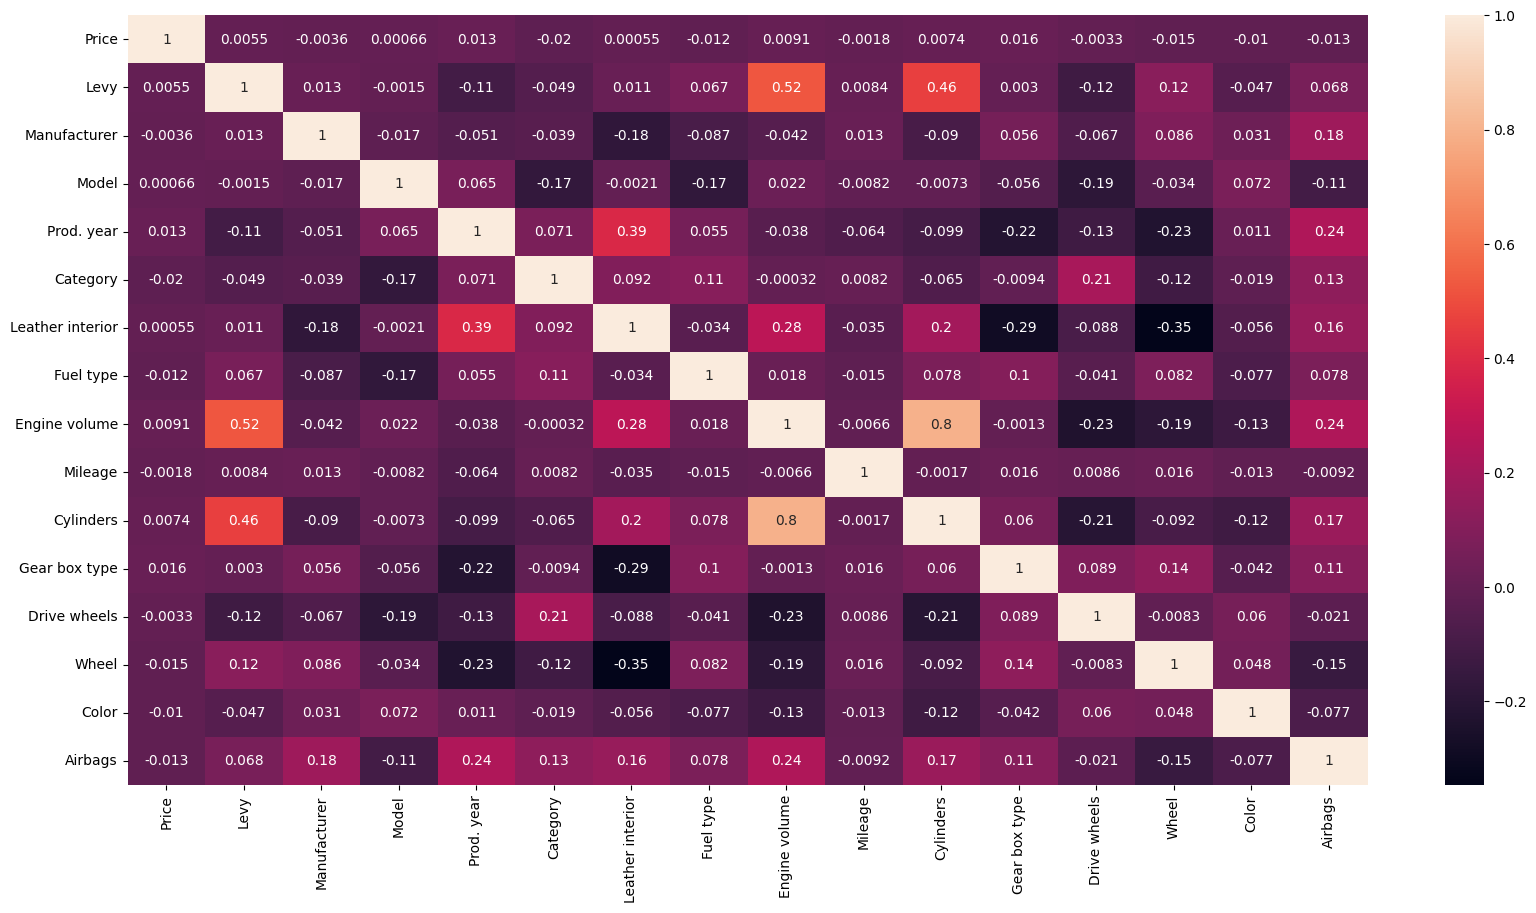

In [29]:
data = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(data,annot=True)

In [30]:
X = df.drop("Price",axis=1)
y=df["Price"]

In [31]:
Xtrain, Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)


In [32]:
Xtrain

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
18528,1714.000000,36,785,2017,4,1,5,39,55403.0,6.0,0,2,0,1,0
16845,1850.000000,36,601,2008,9,1,1,39,122874.0,6.0,0,2,0,1,12
12941,906.299205,16,1056,2017,1,0,5,25,59805.0,4.0,2,2,0,1,12
18867,790.000000,11,937,2009,9,1,5,17,83000.0,4.0,0,1,0,12,4
6167,878.000000,58,1154,2009,9,0,2,19,195000.0,4.0,0,1,0,14,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11413,3989.000000,24,1198,2006,4,1,5,59,219200.0,8.0,0,0,0,12,16
12106,1399.000000,36,601,2010,9,1,1,39,256914.0,6.0,0,0,0,7,12
5429,906.299205,5,68,1995,3,0,5,21,0.0,6.0,1,2,0,1,0
861,1018.000000,5,97,2011,9,1,5,33,70000.0,6.0,2,2,0,14,12


In [33]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
Xtrain = scalar.fit_transform(Xtrain)
Xtest = scalar.fit_transform(Xtest)

In [34]:
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [35]:
ypred = model.predict(Xtest)
ypred

array([ 8500.68902357,  -333.7322626 , 14602.10676268, ...,
       24254.74897171,  9588.08269227, 17913.03237362])

In [36]:
print("Training eff :", model.score(Xtrain,ytrain))
print("Testing eff :", model.score(Xtest,ytest))

Training eff : 0.0019599734650495027
Testing eff : -0.01390097159570236


In [37]:
print("metrics : ")
r2 = r2_score(ytest,ypred)
print("R2 : ",r2)
N = df.shape[0]
P=df.shape[1]
adj_r2 = 1-(((1-r2**2)*(N-1))/(N-P-1))
print("Adjusted R2 : ",adj_r2)
print("MSE : ",mean_squared_error(ytest,ypred))
print("MAE : ",mean_absolute_error(ytest,ypred))

metrics : 
R2 :  -0.01390097159570236
Adjusted R2 :  -0.0006528468839628321
MSE :  330769471.2326425
MAE :  12798.217813997479
